# Ridge Regression

In [4]:
#import librarires
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
# import librarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# load the dataset
df=pd.read_csv("C:\\Users\\guntu\\OneDrive\\Desktop\\Ridge Regression\\Ridge Regression\\Ridge_Regression_HousingData.csv")
df

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Median House Value
0,0,3.9816,27.0,4.928668,1.122476,3009.0,4.049798,33.73,-117.93,1.795
1,1,3.4531,23.0,4.021339,1.099338,2511.0,1.847682,34.14,-118.13,2.109
2,2,6.3942,4.0,5.681272,1.095774,5613.0,2.176425,37.78,-121.95,3.567
3,3,2.2243,32.0,5.685221,1.009597,1542.0,2.959693,38.69,-121.45,0.892
4,4,3.0217,9.0,5.006324,1.071146,3265.0,2.581028,37.69,-121.04,1.609
...,...,...,...,...,...,...,...,...,...,...
16507,16507,5.7214,16.0,6.231429,0.917143,1133.0,3.237143,34.12,-117.68,2.594
16508,16508,2.7254,41.0,3.834829,0.985637,986.0,1.770197,34.02,-118.47,4.444
16509,16509,2.5288,16.0,5.315638,1.060258,2463.0,3.533716,36.98,-120.05,0.618
16510,16510,2.6165,34.0,4.593168,1.031056,1166.0,3.621118,33.89,-118.24,1.009


In [7]:
# data preprocessing
df.head()

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Median House Value
0,0,3.9816,27.0,4.928668,1.122476,3009.0,4.049798,33.73,-117.93,1.795
1,1,3.4531,23.0,4.021339,1.099338,2511.0,1.847682,34.14,-118.13,2.109
2,2,6.3942,4.0,5.681272,1.095774,5613.0,2.176425,37.78,-121.95,3.567
3,3,2.2243,32.0,5.685221,1.009597,1542.0,2.959693,38.69,-121.45,0.892
4,4,3.0217,9.0,5.006324,1.071146,3265.0,2.581028,37.69,-121.04,1.609


In [8]:
df.duplicated().any()

np.False_

In [9]:
df.shape

(16512, 10)

In [10]:
# check the information about the datasets
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          16512 non-null  int64  
 1   MedInc              16512 non-null  float64
 2   HouseAge            16512 non-null  float64
 3   AveRooms            16512 non-null  float64
 4   AveBedrms           16512 non-null  float64
 5   Population          16512 non-null  float64
 6   AveOccup            16512 non-null  float64
 7   Latitude            16512 non-null  float64
 8   Longitude           16512 non-null  float64
 9   Median House Value  16512 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.3 MB


In [11]:
# check the missing value the in df
df.isnull().sum()

Unnamed: 0            0
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
Median House Value    0
dtype: int64

In [12]:
# check the describe
df.describe()

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Median House Value
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,8255.500000,3.859050,28.592902,5.429562,1.096896,1429.927689,3.055425,35.632512,-119.565484,2.062298
std,4766.748158,1.887126,12.615380,2.552593,0.494423,1149.664255,10.780690,2.133356,1.998334,1.151592
min,0.000000,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,4127.750000,2.562500,18.000000,4.439906,1.006131,785.000000,2.430205,33.930000,-121.790000,1.189000
50%,8255.500000,3.531300,29.000000,5.227757,1.048689,1168.000000,2.814815,34.260000,-118.500000,1.786000
75%,12383.250000,4.725000,37.000000,6.051724,1.099955,1729.000000,3.278159,37.710000,-118.007500,2.646000
max,16511.000000,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.490000,5.000010


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Unnamed: 0'),
  Text(1, 0, 'MedInc'),
  Text(2, 0, 'HouseAge'),
  Text(3, 0, 'AveRooms'),
  Text(4, 0, 'AveBedrms'),
  Text(5, 0, 'Population'),
  Text(6, 0, 'AveOccup'),
  Text(7, 0, 'Latitude'),
  Text(8, 0, 'Longitude'),
  Text(9, 0, 'Median House Value')])

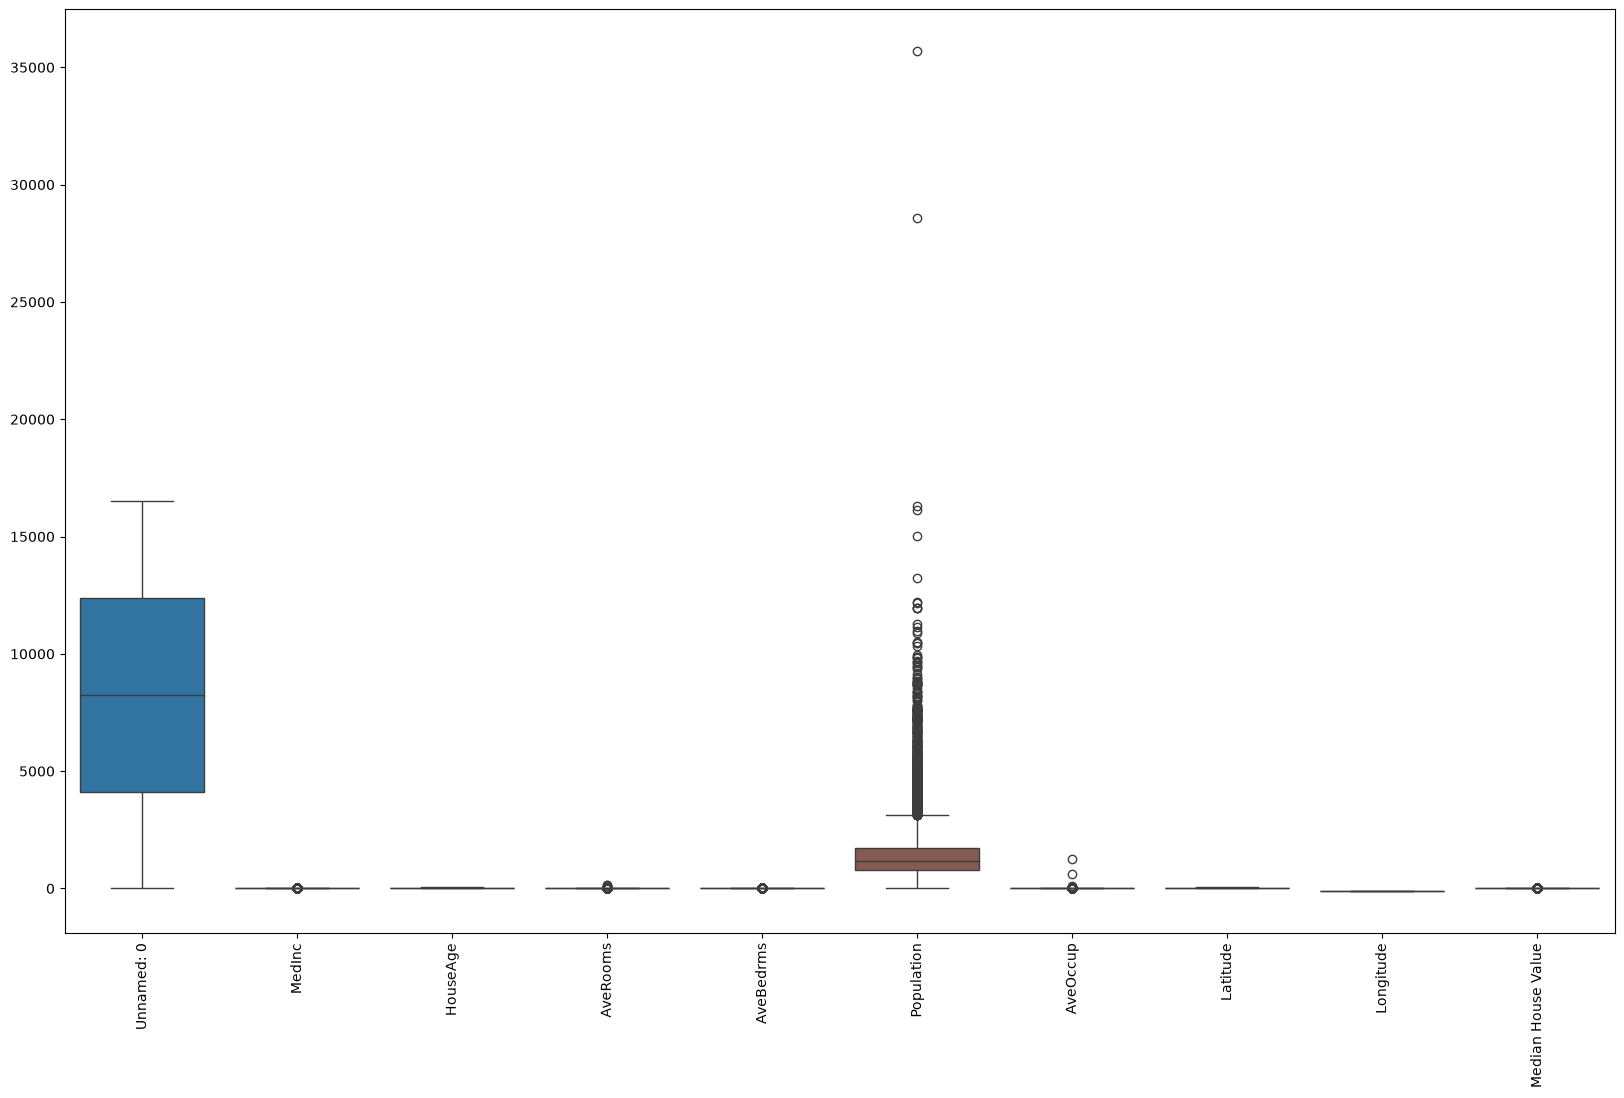

In [13]:
# EDA
# make the box plot
plt.figure(figsize=(20,12))
sns.boxplot(df)
plt.xticks(rotation = 90)

In [14]:
# drop the unnamed:0
df.drop(columns=['Unnamed: 0'],inplace=True)

In [15]:
# Handled the outlier using IQR with Clipping method
outliert_column=df[['MedInc','AveRooms','AveBedrms','Population','AveOccup']]
# outliert_column
for column in outliert_column.columns:
    # find the Q3
    Q3 = df[column].quantile(0.75)
    # find the Q1
    Q1 = df[column].quantile(0.25)
    # find the IQR
    IQR = Q3 - Q1
    # find the upper limit
    upper_limit = Q3 + 1.5 * IQR
    # find the lower limit
    lower_limit = Q1 - 1.5 * IQR
    # clipping the outlier
    df[column] = df[column].clip(lower =lower_limit, upper =upper_limit)



([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Median House Value')])

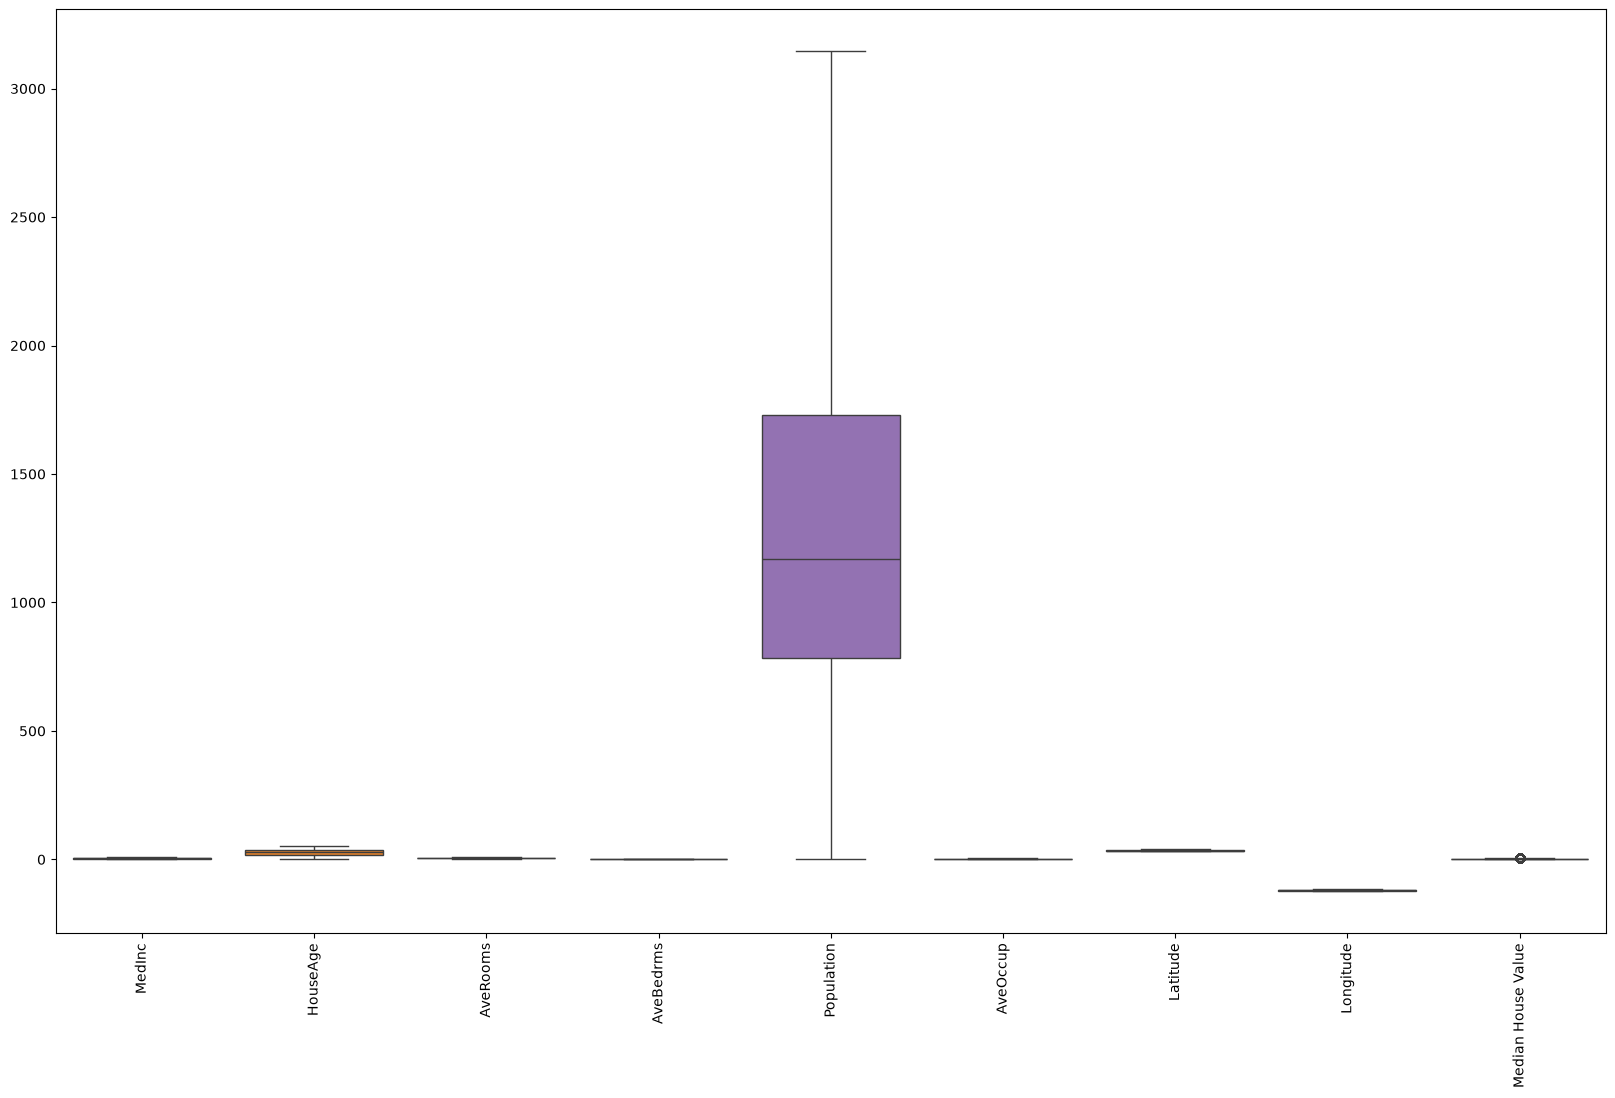

In [16]:
# EDA
# make the box plot
plt.figure(figsize=(20,12))
sns.boxplot(df)
plt.xticks(rotation = 90)

In [17]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Median House Value'],
      dtype='str')

In [18]:
# X = Input features
X = df.drop("Median House Value", axis=1)

# y = Target/output
y = df["Median House Value"]

In [19]:
print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  3.9816      27.0  4.928668   1.122476      3009.0  4.049798     33.73   
1  3.4531      23.0  4.021339   1.099338      2511.0  1.847682     34.14   
2  6.3942       4.0  5.681272   1.095774      3145.0  2.176425     37.78   
3  2.2243      32.0  5.685221   1.009597      1542.0  2.959693     38.69   
4  3.0217       9.0  5.006324   1.071146      3145.0  2.581028     37.69   

   Longitude  
0    -117.93  
1    -118.13  
2    -121.95  
3    -121.45  
4    -121.04  
0    1.795
1    2.109
2    3.567
3    0.892
4    1.609
Name: Median House Value, dtype: float64


In [25]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (13209, 8)
X_test: (3303, 8)
y_train: (13209,)
y_test: (3303,)


In [27]:
# load the Ridge regression model from sklearn
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
print(y_pred[:10])
print(y_test.head(10).values)
print(y_pred[:10])

[2.77116724 2.4917461  0.67206814 1.49433604 3.65051631 1.81554149
 1.7517863  2.50945753 0.82860319 1.99945177]
[1.929 1.88  1.461 1.149 4.167 1.83  1.119 1.408 0.92  1.595]
[2.77116724 2.4917461  0.67206814 1.49433604 3.65051631 1.81554149
 1.7517863  2.50945753 0.82860319 1.99945177]


In [28]:
# Evaluate the model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.5022199872854521
RMSE: 0.6749121845907017
R2 Score: 0.660009129423587


In [ ]:
# saved the model using joblib
# import joblib

# joblib.dump(ridge_model, "ridge_model.pkl")

# print("Ridge model saved successfully!")

# Same Process Ridge Regression and Lasso Regression also

In [29]:
# load the Lasso regression model from sklearn
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

In [32]:
# Evaluate the Lasso model performance
from sklearn.metrics import mean_squared_error

loss = mean_squared_error(y_test, y_pred_lasso)

print("Loss:", loss)

Loss: 1.0620025597852738


In [33]:
# error metrics for Lasso regression
from sklearn.metrics import mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred_lasso)
mae = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 1.0620025597852738
MAE: 0.8060387639340315
RMSE: 1.0305350842088172
R2 Score: 0.20731930496451012
